# Linear Regression

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
from arviz import convert_to_inference_data, summary
from IPython.display import display
from scipy.linalg import inv, solve
from scipy.stats import gaussian_kde
from tqdm import trange

In [2]:
def mcmc_stats(runs, burnin=0, chain=4, prob=0.95, param_string=None, isvariance=True):
    """
    Posterior statistics

    Inputs
    runs         --- Monte Carlo sample
    burnin       --- the number of runs in the burnin stage
    chain        --- the number of chains used for convergence diagnostics
    prob         --- the posterior probability for interval estimation
    param_string --- the list of parameter names
    isvariance   ---- True if the variance is included

    Outputs
    posterior_statistics ---  table of posterior statistics (Pandas datafarme)
    """
    if runs.shape[0] < burnin:
        raise ValueError('You need to reduce the number of draws to be discarded as burnin.')
    draw = (runs.shape[0] - burnin) // chain
    if runs.shape[0] != burnin + draw * chain:
        raise ValueError('The number of draws must be divided by the number of chains.')
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1])]
    traces = convert_to_inference_data(np.stack([runs[burnin:, i].reshape((chain, draw)) \
                                                 for i in range(runs.shape[1])], axis=2))
    posterior_statistics = summary(traces, hdi_prob=prob)
    posterior_statistics.index = param_string
    return posterior_statistics

In [3]:
def mcmc_plots(runs, burnin=0, param_string=None, isvariance=True):
    """
    Posterior plots

    Inputs
    runs          --- Monte Carlo sample
    burnin        --- the number of runs in the burnin stage
    isvariance   ---- True if the variance is included

    Outputs
    kde_x         --- grid
    kde_posterior --- kernel density estimation
    """
    grid = 250
    k = runs.shape[1]
    kde_x = np.zeros((grid, k))
    kde_posterior = np.zeros((grid, k))
    if isvariance:
        num_b = k - 1
    else:
        num_b = k
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1])]
    fig, ax = plt.subplots(k, 2, num=1, figsize=(8, 1.5*k), facecolor='w')
    for index in range(k):
        mc_trace = runs[burnin:, index]
        if index < num_b:
            x_min = mc_trace.min() - 0.2 * np.abs(mc_trace.min())
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        else:
            x_min = 0.0
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        posterior = gaussian_kde(mc_trace).evaluate(x)
        ax[index, 0].plot(mc_trace, linewidth=0.1)
        ax[index, 0].set_xlim(1, draws)
        ax[index, 0].set_ylabel(y_label)
        ax[index, 1].plot(x, posterior)
        ax[index, 1].set_xlim(x_min, x_max)
        ax[index, 1].set_ylim(0, 1.1*posterior.max())
        ax[index, 1].set_ylabel('Density')
        kde_x[:, index] = x
        kde_posterior[:, index] = posterior
    ax[-1, 0].set_xlabel('Random Sequence')
    ax[-1, 1].set_xlabel('Posterior Distribution')
    plt.tight_layout()
    plt.show
    return kde_x, kde_posterior

## Linear regression model

Consider the linear regression model:

$$
    y = X\beta + \epsilon,\quad \epsilon \sim \mathrm{Normal}(0,\sigma^{2}\mathrm{I}).
$$

where $y$ is a $n\times 1$ vector of the dependent variables and $X$ is a $n\times k$ matrix of the indepenent variables.

Assume the prior of $(\beta,\sigma^{2})$ as

$$
    \beta\sim\mathrm{Normal}(\beta_{0},A_{0}^{-1}),\quad \sigma^{2}\sim\mathrm{Inv.Gamma}\left(\frac{\nu_{0}}2,\frac{\lambda_{0}}2\right),
$$


## Gibbs sampler for the linear regression model

The full conditional posterior distributions of $\beta$ and $\sigma^{2}$ are

$$
    \begin{split}
    \beta|\sigma^{2}, D &\sim \mathrm{Normal}\left(\beta_{\star}, \Sigma_{\star}\right), \\
    \sigma^{2}|\beta, D &\sim \mathrm{Inv.Gamma}\left(\frac{\nu_{\star}}2,\frac{\lambda_{\star}}2\right),
    \end{split}
$$

where

$$
    \begin{split}
        \beta_{\star} &= (\sigma^{-2}X^{\intercal}X+A_{0})^{-1}(\sigma^{-2}X^{\intercal}y + A_{0}\beta_{0}), \\
        \Sigma_{\star} &= (\sigma^{-2}X^{\intercal}X+A_{0})^{-1}, \\
        \nu_{\star} &= n + \nu_{0},\\
        \lambda_{\star} &= (\beta-\hat{\beta})^{\intercal}X^{\intercal}X(\beta-\hat{\beta}) + (y-X\hat{\beta})^{\intercal}(y-X\hat{\beta}) + \lambda_{0}.
    \end{split}
$$


In [4]:
def gibbs_regression(y, X, hyper_param, burnin=1000, draws=10000, rng=None):
    """
    Gibbs sampler for linear regression

    Inputs
    y      --- regressand (n x 1)
    X      --- regressors (n x k)
    hyper_param = [b0, A0, a_sigma, b_sigma]
    b0     --- the prior mean vector of the regression coefficients
    A0     --- the prior precision matrix of the regression coefficients
    nu0    --- the prior shape parameter for the error variance
    lam0   --- the prior scale parameter for the error variance
    burnin --- the number of runs in the burnin stage
    draws  --- the number of runs in the sampling stage
    rng    --- the initial state of the random number generator

    Outputs
    runs    --- Monte Carlo sample (draws x (k + 1))
                column 0:(k-1)    regression coefficients
                column k          error variance
    """
    if rng == None:
        rng = np.random.default_rng(seed=1234)
    iterations = burnin + draws
    b0, A0, nu0, lam0 = hyper_param
    A0b0 = A0 @ b0
    n, k = X.shape
    sigma_shape = 0.5 * (n + nu0)
    XX = X.T @ X
    Xy = X.T @ y
    b_ols = solve(XX, Xy)
    rss = np.square(y - X @ b_ols).sum()
    b = b_ols
    sigma2 = rss / (n - k)
    runs = np.empty((iterations, k + 1))
    for it in trange(iterations):
        sigma_scale = 0.5 * ((b - b_ols) @ XX @ (b - b_ols) + rss + lam0)
        sigma2 = sigma_scale / rng.gamma(sigma_shape)
        cov_b = inv(XX / sigma2 + A0)
        mean_b = cov_b @ (Xy / sigma2 + A0b0)
        b = rng.multivariate_normal(mean_b, cov_b)
        runs[it, :-1] = b
        runs[it, -1] = sigma2
    return runs

In [5]:
n = 50
rng = np.random.default_rng(seed=99)
u = rng.normal(scale=0.7, size=n)
x1 = rng.uniform(low=-np.sqrt(3.0), high=np.sqrt(3.0), size=n)
x2 = rng.uniform(low=-np.sqrt(3.0), high=np.sqrt(3.0), size=n)
x3 = rng.uniform(low=-np.sqrt(3.0), high=np.sqrt(3.0), size=n)
y = 1.0 + 2.0 * x1 - x2 + u
X = np.stack((np.ones(n), x1, x2, x3), axis=1)

In [6]:
n, k = X.shape
b0 = np.zeros(k)
A0 = 0.01 * np.eye(k)
nu0 = 0.002
lam0 = 0.002
hyper_param = [b0, A0, nu0, lam0]

## Gibbs sampler


In [7]:
burnin = 5000
draws = 20000
runs = gibbs_regression(y, X, hyper_param, burnin=burnin, draws=draws, rng=rng)

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [00:01<00:00, 21371.23it/s]


In [8]:
results = mcmc_stats(runs, burnin=burnin)
display(results)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
$\beta_0$,1.177,0.089,1.002,1.354,0.001,0.000,19779.0,19700.0,1.0
$\beta_1$,1.863,0.095,1.673,2.049,0.001,0.000,19466.0,19403.0,1.0
$\beta_2$,-1.066,0.089,-1.241,-0.892,0.001,0.000,20124.0,19386.0,1.0
$\beta_3$,0.016,0.098,-0.178,0.207,0.001,0.001,19859.0,19247.0,1.0
$\sigma^{2}$,0.386,0.084,0.236,0.551,0.001,0.001,16998.0,18914.0,1.0


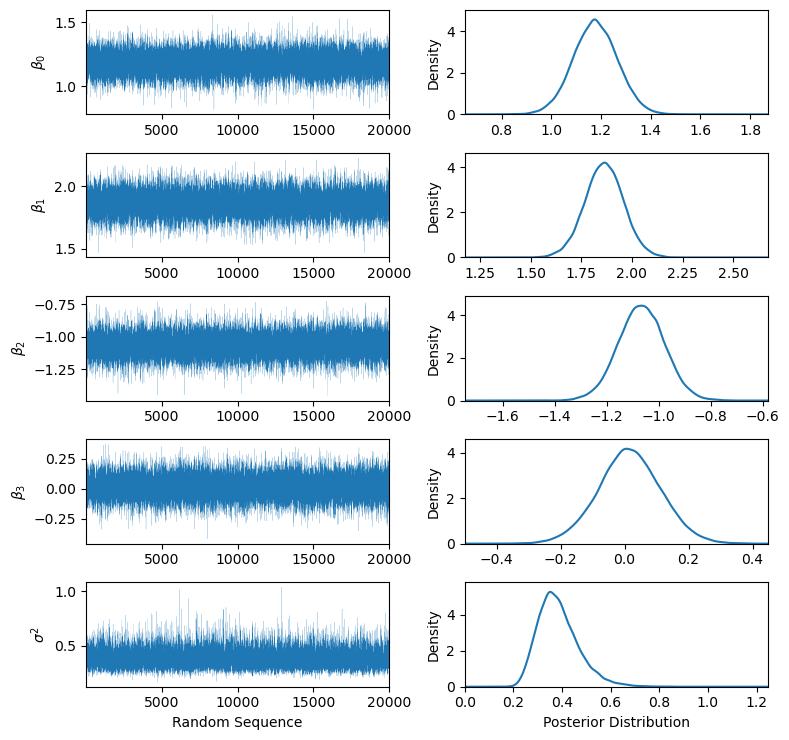

In [9]:
_ = mcmc_plots(runs, burnin=burnin)

## Implementaion with PyMC


In [10]:
regression_model = pm.Model()
with regression_model:
    b = pm.MvNormal('b', mu=b0, tau=A0, shape=k)
    sigma2 = pm.InverseGamma('sigma2', alpha=0.5*nu0, beta=0.5*lam0)
    y_hat = X @ b
    likelihood = pm.Normal('y', mu=y_hat, sigma=pm.math.sqrt(sigma2), observed=y)

In [11]:
n_draws = 5000
n_chains = 4
n_tune = 5000
with regression_model:
    trace = pm.sample(draws=n_draws, chains=n_chains, tune=n_tune, target_accept=0.9, random_seed=rng)
runs_pymc = np.vstack(([trace.posterior['b'].to_numpy()[:, :, index].flatten() for index in range(k)],
                       trace.posterior['sigma2'].to_numpy().flatten())).T

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, sigma2]


Output()

Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 4 seconds.


In [12]:
results_pymc = mcmc_stats(runs_pymc)
display(results_pymc)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
$\beta_0$,1.176,0.089,1.001,1.350,0.001,0.001,22004.0,15853.0,1.0
$\beta_1$,1.863,0.096,1.665,2.043,0.001,0.001,21371.0,15694.0,1.0
$\beta_2$,-1.065,0.088,-1.232,-0.888,0.001,0.001,21015.0,14689.0,1.0
$\beta_3$,0.018,0.097,-0.172,0.209,0.001,0.001,21057.0,15891.0,1.0
$\sigma^{2}$,0.385,0.084,0.241,0.556,0.001,0.001,18555.0,14521.0,1.0


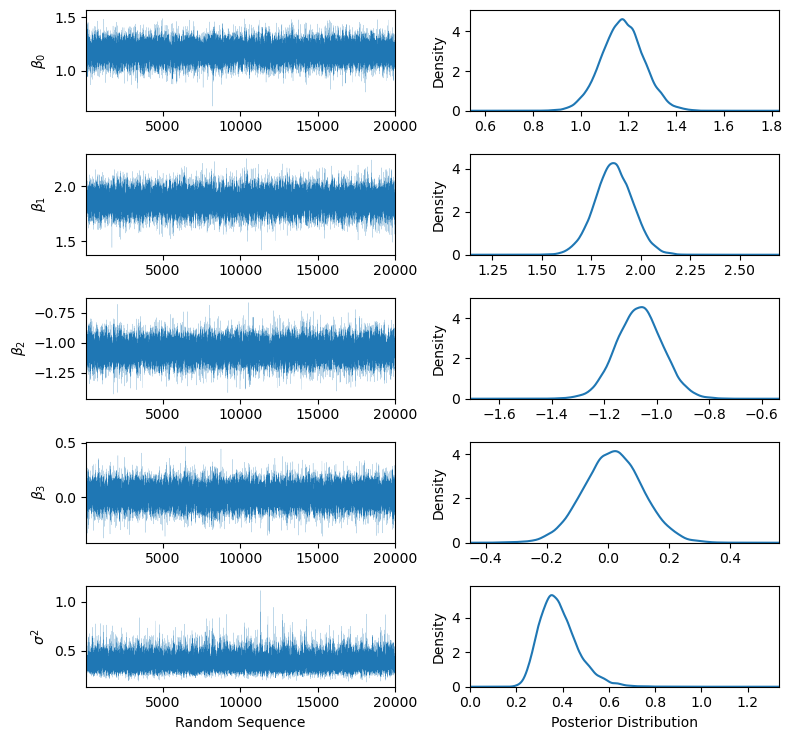

In [13]:
_ = mcmc_plots(runs_pymc)